In [ ]:
import random
import matplotlib.pyplot as plt
N = 8  # number of queens
POP_SIZE = 100
GENERATIONS = 200
MUTATION_RATE = 0.01

#Create Individual (Permutation Encoding)

In [ ]:
def create_individual():
    individual = list(range(N))
    random.shuffle(individual)
    return individual

#Create Population

In [ ]:
def create_population():
    return [create_individual() for _ in range(POP_SIZE)]

#Fitness Function (Minimize Conflicts)


In [ ]:
def fitness(individual):
    conflicts = 0

    for i in range(N):
        for j in range(i + 1, N):
            # diagonal conflict
            if abs(individual[i] - individual[j]) == abs(i - j):
                conflicts += 1

    return -conflicts  # maximize fitness (less conflicts)

#Selection (Tournament)

In [ ]:
def selection(population, k=3):
    selected = random.sample(population, k)
    return max(selected, key=fitness)

#Crossover

In [ ]:
def crossover(p1, p2):
    size = len(p1)
    start, end = sorted(random.sample(range(size), 2))

    child = [None] * size
    child[start:end] = p1[start:end]

    fill = [x for x in p2 if x not in child]

    j = 0
    for i in range(size):
        if child[i] is None:
            child[i] = fill[j]
            j += 1

    return child

#Mutation (Swap Mutation)

In [ ]:
def mutate(individual):
    if random.random() < MUTATION_RATE:
        i, j = random.sample(range(N), 2)
        individual[i], individual[j] = individual[j], individual[i]
    return individual

#Genetic Algorithm Loop

In [ ]:
def genetic_algorithm():
    population = create_population()
    best_history = []

    for gen in range(GENERATIONS):
        new_population = []

        # Elitism (keep best)
        best = max(population, key=fitness)
        new_population.append(best)

        while len(new_population) < POP_SIZE:
            p1 = selection(population)
            p2 = selection(population)

            child = crossover(p1, p2)
            child = mutate(child)

            new_population.append(child)

        population = new_population

        best = max(population, key=fitness)
        best_conflicts = -fitness(best)
        best_history.append(best_conflicts)

        print(f"Gen {gen}: Conflicts = {best_conflicts}")

        if best_conflicts == 0:
            break

    return best, best_history

#Visualization (Chess Board)

In [ ]:
def plot_board(solution):
    plt.figure(figsize=(5,5))

    for i in range(N):
        for j in range(N):
            color = 'white' if (i + j) % 2 == 0 else 'gray'
            plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, color=color))

    for row in range(N):
        col = solution[row]
        plt.text(col + 0.5, row + 0.5, 'Q',
                 ha='center', va='center', fontsize=16, color='red')

    plt.xlim(0, N)
    plt.ylim(0, N)
    plt.gca().invert_yaxis()
    plt.title("N-Queens Solution")
    plt.show()

#Plot Fitness Evolution

In [ ]:
def plot_fitness(history):
    plt.plot(history)
    plt.title("Conflicts over Generations")
    plt.xlabel("Generation")
    plt.ylabel("Conflicts")
    plt.grid()
    plt.show()

#Run Everything

Gen 0: Conflicts = 1
Gen 1: Conflicts = 1
Gen 2: Conflicts = 0

Best Solution: [3, 0, 4, 7, 1, 6, 2, 5]
Final Conflicts: 0


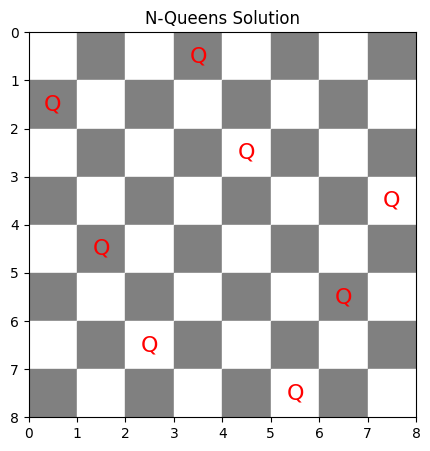

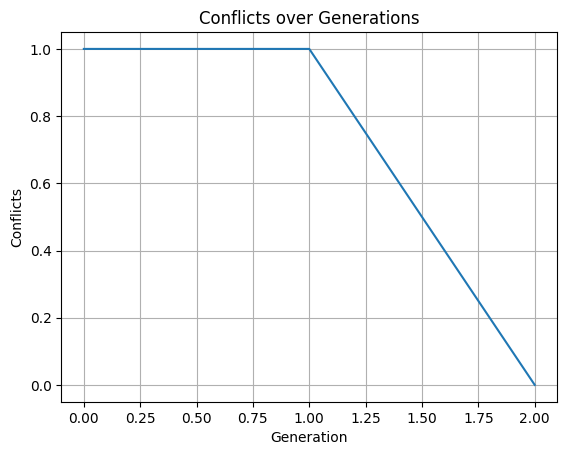

In [ ]:
best_solution, history = genetic_algorithm()

print("\nBest Solution:", best_solution)
print("Final Conflicts:", -fitness(best_solution))

plot_board(best_solution)
plot_fitness(history)

In [ ]:
(3,2)  (4,2) ===> 4-3 = 1 , 2-2=0

NameError: name 'population' is not defined